# Loan Default Prediction using Machine Learning
### Darshan University — Computer Engineering Department — ML Project

**Dataset:** Loan Default Prediction (Kaggle) — `https://www.kaggle.com/datasets/nikhil1e9/loan-default`


**Objective:** Develop a machine learning classification model that predicts whether a borrower will default based on their financial, demographic and loan-related attributes.

**Target:** Default

Default = 0 → No Default


Default = 1 → Default

---

### Problem Statement
Banks approve thousands of loans every year. Some customers fail to repay their loans, resulting in financial losses for the institution. The objective of this project is to develop a Machine Learning model that predicts whether a customer is **likely to default on a loan**, using their financial, employment, and demographic details. Early identification of high-risk applicants helps banks make better lending decisions and reduce non-performing assets (NPAs).

### Dataset Summary

| Item | Description |
|---|---|
| Dataset Name | Loan Default Prediction |
| Domain | Banking |
| Source | Kaggle |
| Target Variable | `Default` |
| Problem Type | Binary Classification (0 = No Default, 1 = Default) |

**Features used:**
- Loan Amount
- Annual Income
- Age
- Employment Type
- Credit Score
- Loan Term
- Interest Rate
- Number of Dependents
- Existing Loans
- Property Area

### Initial Observations
- The dataset contains a mix of **numerical** (Loan Amount, Income, Age, Credit Score...) and **categorical** (Employment Type, Property Area...) features.
- Missing values may be present and need to be handled.
- Some numerical features (e.g., Income, Loan Amount) are likely to contain outliers.
- The target variable `Default` is imbalanced in most real-world lending datasets (fewer defaulters than non-defaulters) — this will be checked and considered during evaluation.
- Data preprocessing (cleaning, encoding, scaling) is required before model training.


In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Loan_Default.csv')

In [5]:
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [6]:
df.head() # First 5 rows

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [7]:
df.tail() # Last 5 rows

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0
255346,ZTH91CGL0B,62,22418,18481,636,113,2,6.73,12,0.48,Bachelor's,Unemployed,Divorced,Yes,No,Education,Yes,0


In [8]:
df.sample() # Random Rows

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
246637,48EQ1YCWIW,66,117636,66124,599,5,4,10.39,48,0.6,High School,Unemployed,Divorced,Yes,Yes,Business,Yes,0


In [9]:
df.sample(5) # Random 5 Rows

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
210581,MGN1PMENF3,57,149526,121377,471,75,3,9.89,24,0.11,High School,Full-time,Married,No,No,Business,No,0
135323,CW101B5M21,63,84956,237953,476,59,2,4.93,24,0.31,High School,Unemployed,Single,Yes,Yes,Education,No,0
179412,DCTFRLSU00,67,68499,41161,656,83,4,2.63,60,0.21,Bachelor's,Unemployed,Single,No,No,Other,No,0
65969,KUNBNNE1LL,30,142825,32577,500,85,3,13.93,12,0.10,High School,Part-time,Single,Yes,Yes,Home,Yes,0
193201,F6FG2XASVW,57,40734,240845,365,72,2,15.65,48,0.61,PhD,Part-time,Married,Yes,No,Home,Yes,0


In [7]:
df.shape # Dataset Shape

(255347, 18)

In [7]:
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

Rows    : 255347
Columns : 18


In [8]:
df.index # Dataset Index

RangeIndex(start=0, stop=255347, step=1)

In [9]:
df.info() # Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [11]:
df.dtypes # Data Types

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

In [13]:
df.columns # Column Names

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [14]:
df.nunique() # Number of Unique Values

LoanID            255347
Age                   52
Income            114620
LoanAmount        158729
CreditScore          550
MonthsEmployed       120
NumCreditLines         4
InterestRate        2301
LoanTerm               5
DTIRatio              81
Education              4
EmploymentType         4
MaritalStatus          3
HasMortgage            2
HasDependents          2
LoanPurpose            5
HasCoSigner            2
Default                2
dtype: int64

In [15]:
df.describe() # Categorical Statistical Summary

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [20]:
df.describe(include='object') # Categorical Statistical Summary

,LoanID,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
count,255347,255347,255347,255347,255347,255347,255347,255347
unique,255347,4,4,3,2,2,5,2
top,ZTH91CGL0B,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes
freq,1,64366,64161,85302,127677,127742,51298,127701


In [26]:
df['Default'].value_counts() # Target Distribution

Default
0    225694
1     29653
Name: count, dtype: int64

In [6]:
# Target Percentage
df['Default'].value_counts(normalize=True) * 100

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

In [ ]:
# 88.39% → No Default
# 11.61% → Default

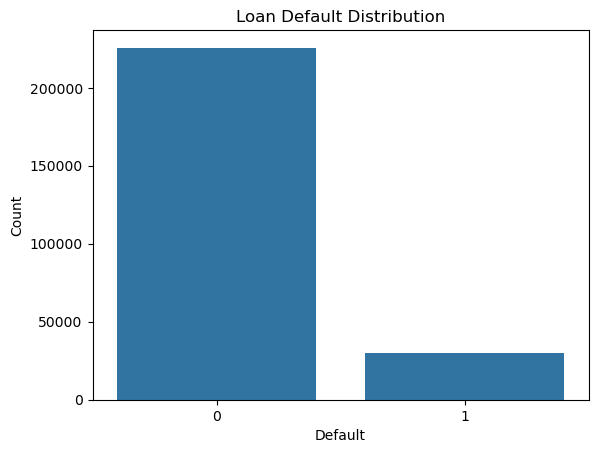

In [9]:
# Target Visualization
sns.countplot(x='Default', data=df)

plt.title('Loan Default Distribution')
plt.xlabel('Default')
plt.ylabel('Count')

plt.show()

# No Default vs Default

In [41]:
# Missing Values
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [44]:
# Missing Value Percentage
df.isnull().mean() * 100

LoanID            0.0
Age               0.0
Income            0.0
LoanAmount        0.0
CreditScore       0.0
MonthsEmployed    0.0
NumCreditLines    0.0
InterestRate      0.0
LoanTerm          0.0
DTIRatio          0.0
Education         0.0
EmploymentType    0.0
MaritalStatus     0.0
HasMortgage       0.0
HasDependents     0.0
LoanPurpose       0.0
HasCoSigner       0.0
Default           0.0
dtype: float64

In [45]:
# Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [52]:
# Numerical Median
df.median(numeric_only=True)

Age                   43.00
Income             82466.00
LoanAmount        127556.00
CreditScore          574.00
MonthsEmployed        60.00
NumCreditLines         2.00
InterestRate          13.46
LoanTerm              36.00
DTIRatio               0.50
Default                0.00
dtype: float64

In [53]:
# Numerical Mode
df.mode(numeric_only=True).iloc[0]

Age                  55.00
Income            69492.00
LoanAmount        95419.00
CreditScore         630.00
MonthsEmployed       56.00
NumCreditLines        2.00
InterestRate         14.92
LoanTerm             48.00
DTIRatio              0.67
Default               0.00
Name: 0, dtype: float64

In [54]:
# Minimum Values
df.min(numeric_only=True)

Age                  18.0
Income            15000.0
LoanAmount         5000.0
CreditScore         300.0
MonthsEmployed        0.0
NumCreditLines        1.0
InterestRate          2.0
LoanTerm             12.0
DTIRatio              0.1
Default               0.0
dtype: float64

In [55]:
# Maximum Values
df.max(numeric_only=True)

Age                   69.0
Income            149999.0
LoanAmount        249999.0
CreditScore          849.0
MonthsEmployed       119.0
NumCreditLines         4.0
InterestRate          25.0
LoanTerm              60.0
DTIRatio               0.9
Default                1.0
dtype: float64

In [56]:
# Standard Deviation
df.std(numeric_only=True)

Age                  14.990258
Income            38963.013729
LoanAmount        70840.706142
CreditScore         158.903867
MonthsEmployed       34.643376
NumCreditLines        1.117018
InterestRate          6.636443
LoanTerm             16.969330
DTIRatio              0.230917
Default               0.320379
dtype: float64

In [10]:
# Memory Usage
df.memory_usage(deep=True)

Index                  132
LoanID            15065473
Age                2042776
Income             2042776
LoanAmount         2042776
CreditScore        2042776
MonthsEmployed     2042776
NumCreditLines     2042776
InterestRate       2042776
LoanTerm           2042776
DTIRatio           2042776
Education         14557535
EmploymentType    15128774
MaritalStatus     14299453
HasMortgage       13150374
HasDependents     13150439
LoanPurpose       14044522
HasCoSigner       13150398
Default            2042776
dtype: int64

# Week 2 — Data Cleaning, Preprocessing & EDA

In [12]:
# Create Clean Copy
df_clean = df.copy()

In [13]:
# Check Missing Values
print("Total Missing Values:",
      df_clean.isnull().sum().sum())

df_clean.isnull().sum()

Total Missing Values: 0


LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [14]:
# Check Duplicate Rows
print("Duplicate Rows:",
      df_clean.duplicated().sum())

Duplicate Rows: 0


In [15]:
# Remove Duplicate Rows
df_clean.drop_duplicates(inplace=True)

In [16]:
# Check Data Types
df_clean.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

In [17]:
# Identify Numerical Columns
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

numeric_cols.remove('Default')

print(numeric_cols)

['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']


In [18]:
# Remove LoanID
df_clean.drop('LoanID', axis=1, inplace=True)

In [19]:
# Check Shape After Removing LoanID
print("Rows    :", df_clean.shape[0])
print("Columns :", df_clean.shape[1])

Rows    : 255347
Columns : 17


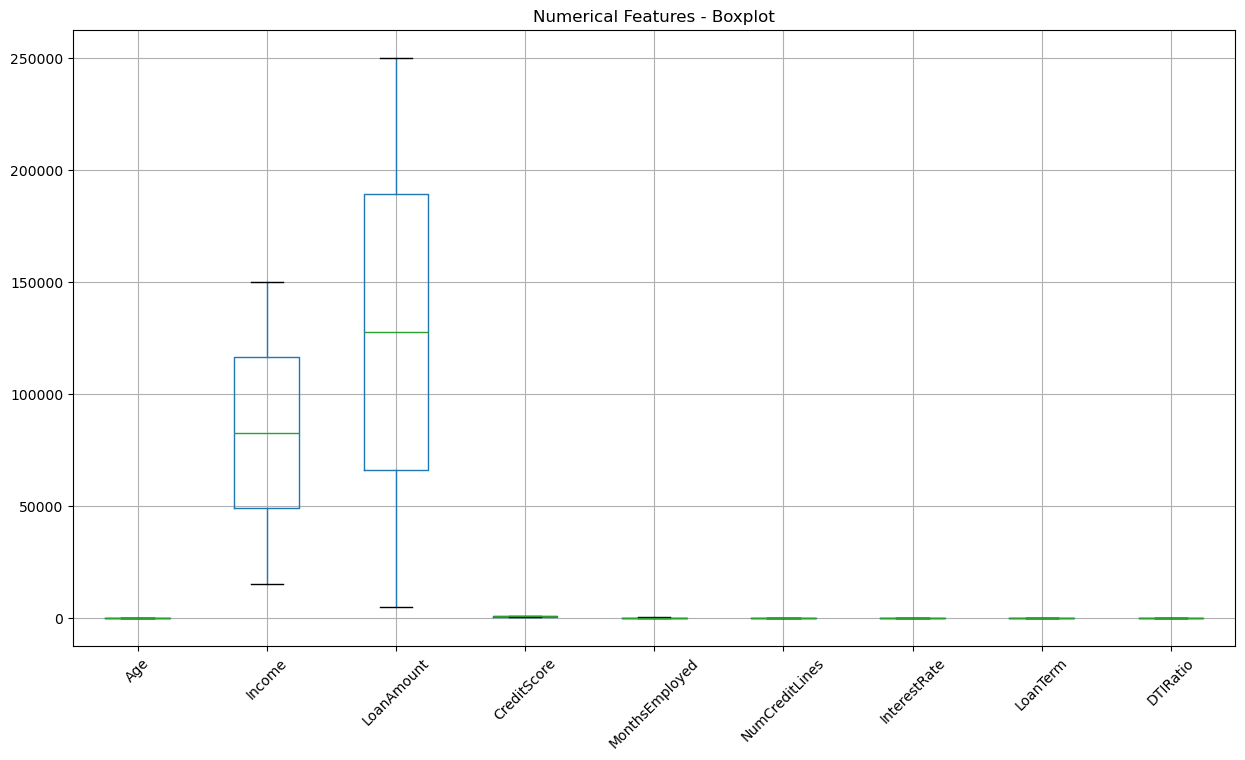

In [20]:
# Numerical Boxplots
plt.figure(figsize=(15, 8))

df_clean[numeric_cols].boxplot()

plt.xticks(rotation=45)
plt.title('Numerical Features - Boxplot')

plt.show()

# IQR Method

In [21]:
# IQR Outlier Detection
for col in numeric_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower) |
        (df_clean[col] > upper)
    ]

    print(col, ":", len(outliers))

Age : 0
Income : 0
LoanAmount : 0
CreditScore : 0
MonthsEmployed : 0
NumCreditLines : 0
InterestRate : 0
LoanTerm : 0
DTIRatio : 0


**Outliers were checked using the IQR method.
No IQR-based outliers were detected in the numerical features.
Therefore, no rows were removed due to outliers.**

# Categorical Variables

In [22]:
categorical_cols = df_clean.select_dtypes(include='object').columns

print(categorical_cols)

Index(['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner'],
      dtype='object')


In [23]:
# Categorical Value Counts
for col in categorical_cols:
    print("----------------------------------------------\n", col)
    print(df_clean[col].value_counts())

----------------------------------------------
 Education
Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64
----------------------------------------------
 EmploymentType
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64
----------------------------------------------
 MaritalStatus
MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64
----------------------------------------------
 HasMortgage
HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64
----------------------------------------------
 HasDependents
HasDependents
Yes    127742
No     127605
Name: count, dtype: int64
----------------------------------------------
 LoanPurpose
LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64
---------------------

# EDA

# Numerical Distribution

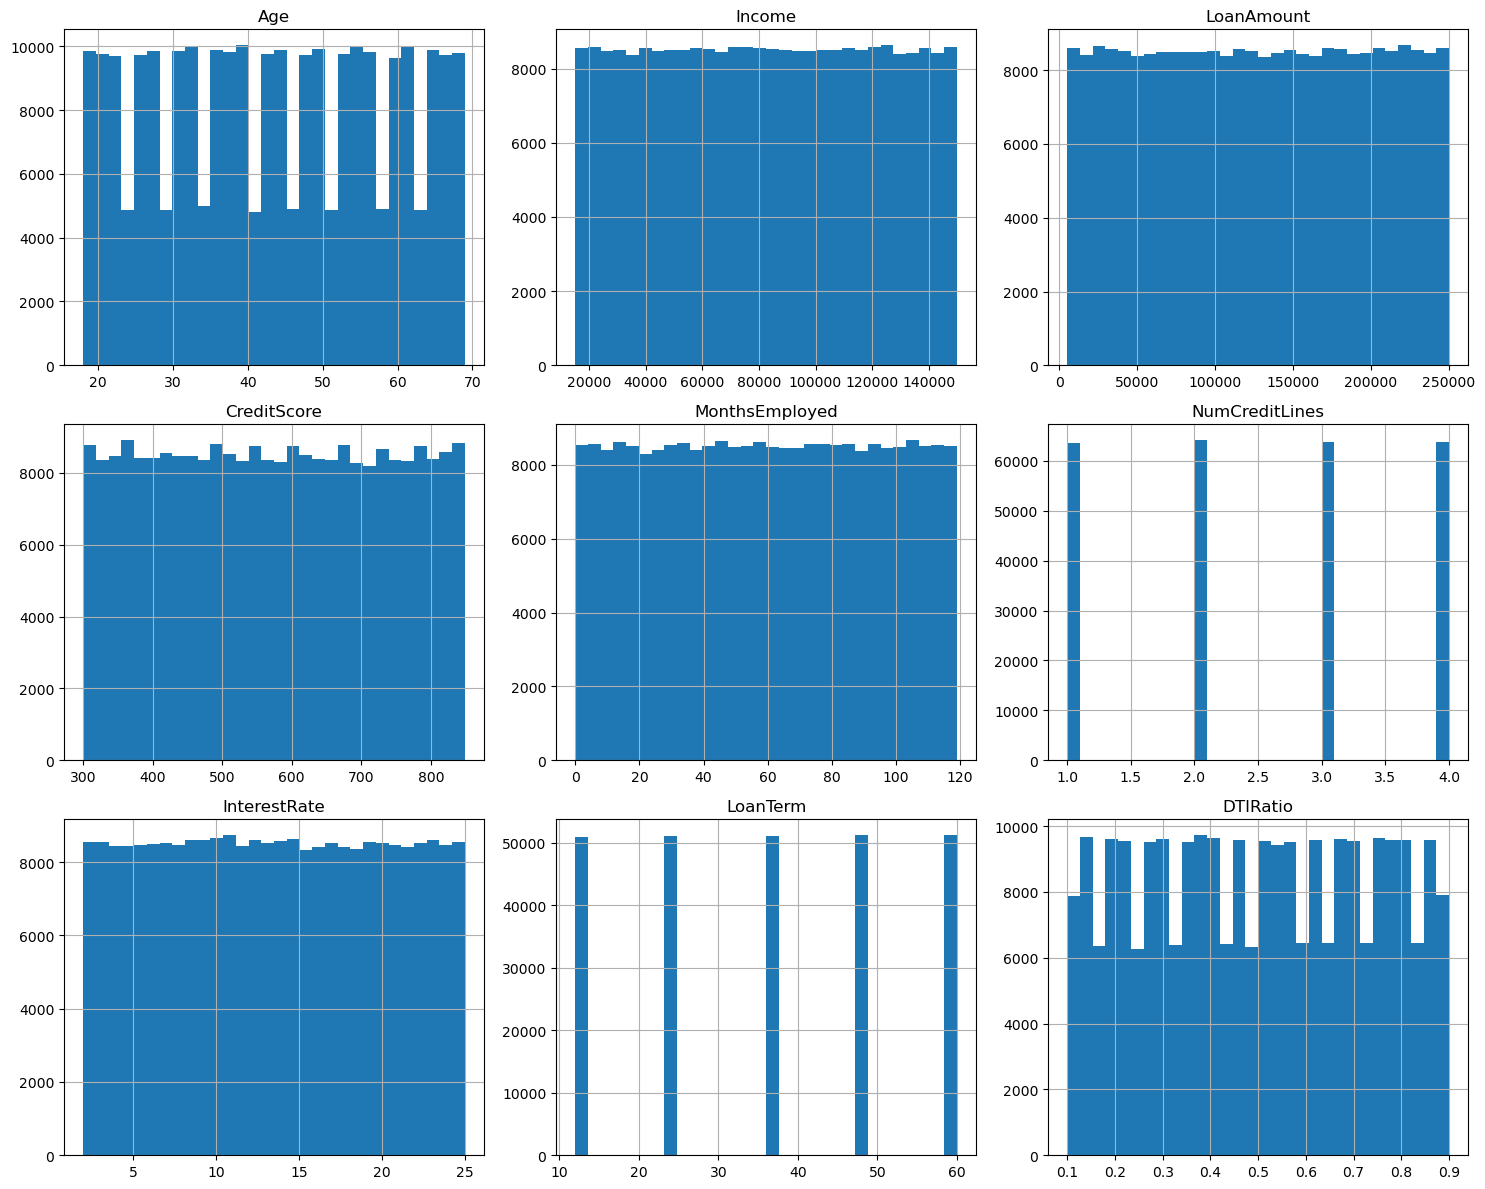

In [24]:
# Numerical Histograms
df_clean[numeric_cols].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

# Boxplots

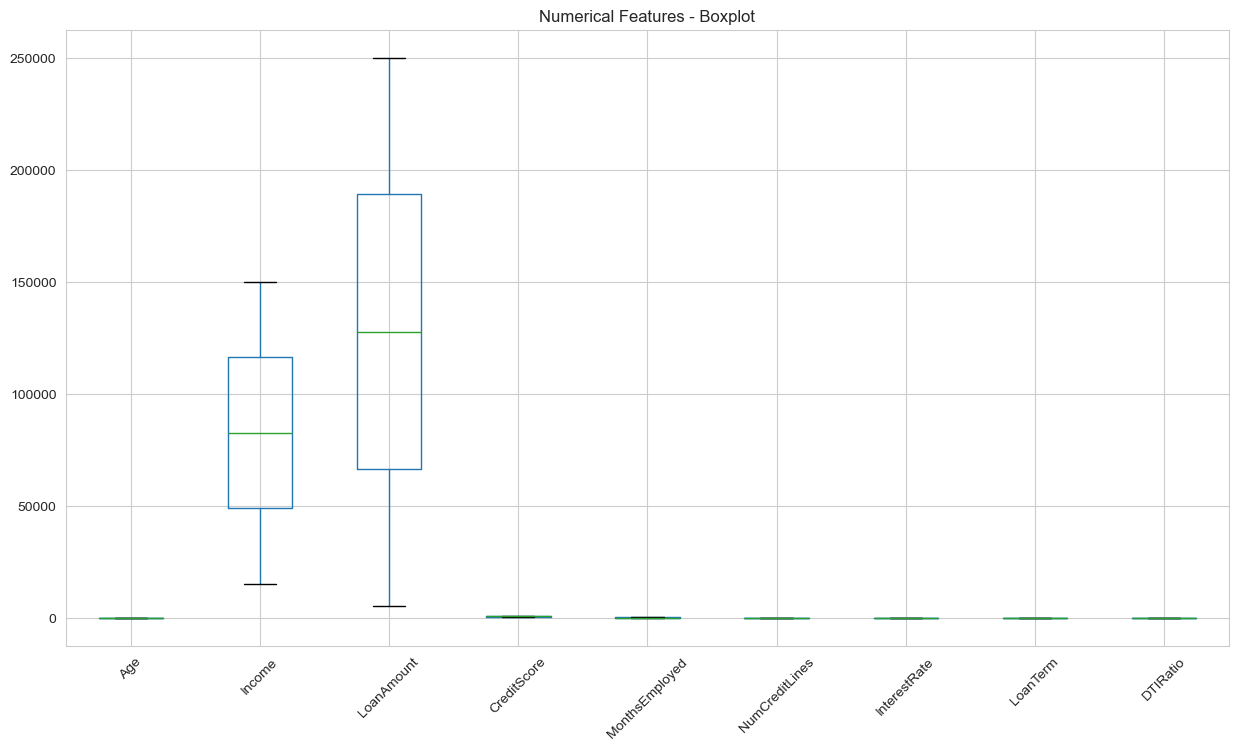

In [86]:
# Numerical Boxplots
plt.figure(figsize=(15, 8))

df_clean[numeric_cols].boxplot()

plt.xticks(rotation=45)
plt.title('Numerical Features - Boxplot')

plt.show()

# Default Distribution

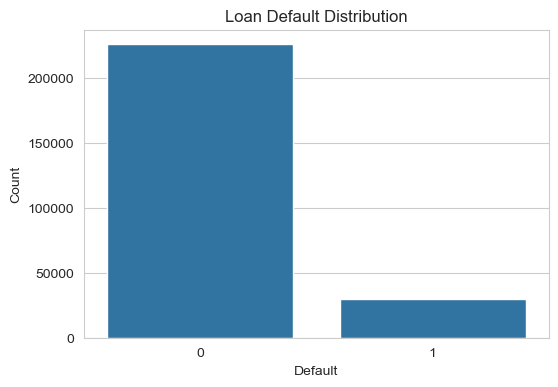

In [87]:
# Default Distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    x='Default',
    data=df_clean
)

plt.title('Loan Default Distribution')
plt.xlabel('Default')
plt.ylabel('Count')

plt.show()

# EDA

# Credit Score vs Default

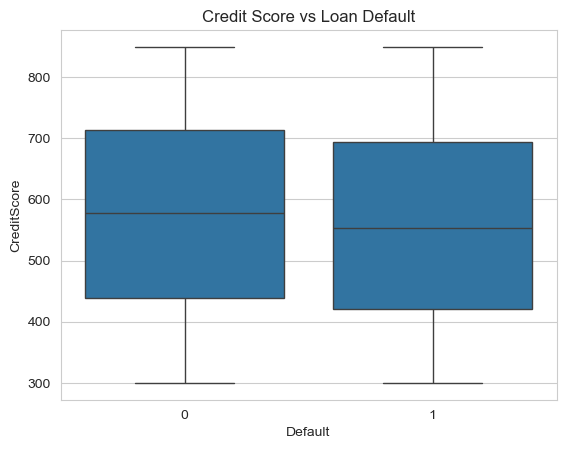

In [89]:
# Credit Score vs Default
sns.boxplot(
    x='Default',
    y='CreditScore',
    data=df_clean
)

plt.title('Credit Score vs Loan Default')

plt.show()

# Income vs Default

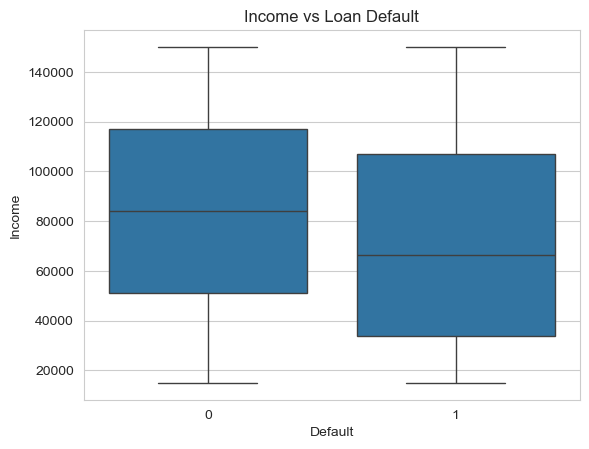

In [91]:
# Income vs Default
sns.boxplot(
    x='Default',
    y='Income',
    data=df_clean
)

plt.title('Income vs Loan Default')

plt.show()

# Loan Amount vs Default

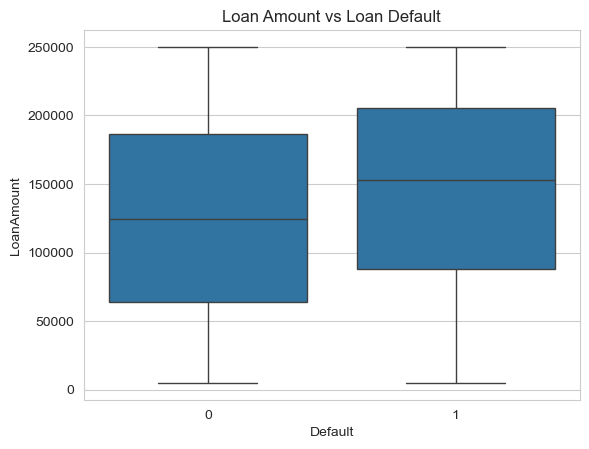

In [92]:
# Loan Amount vs Default
sns.boxplot(
    x='Default',
    y='LoanAmount',
    data=df_clean
)

plt.title('Loan Amount vs Loan Default')

plt.show()

# Week 3 Logistic Regression Using Scikit-Learn.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [26]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=categorical_cols,
    drop_first=True
)

In [28]:
df_encoded.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
0,56,85994,50587,520,80,4,15.23,36,0.44,0,...,False,False,False,True,True,False,False,False,True,True
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,False,True,False,False,False,False,False,False,True,True
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,True,False,False,True,True,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,False,True,False,False,False,True,False,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,True,False,False,False,True,False,False,False,False,False


In [30]:
df_encoded.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default',
       'Education_High School', 'Education_Master's', 'Education_PhD',
       'EmploymentType_Part-time', 'EmploymentType_Self-employed',
       'EmploymentType_Unemployed', 'MaritalStatus_Married',
       'MaritalStatus_Single', 'HasMortgage_Yes', 'HasDependents_Yes',
       'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home',
       'LoanPurpose_Other', 'HasCoSigner_Yes'],
      dtype='object')

In [31]:
print("Rows    :", df_encoded.shape[0])
print("Columns :", df_encoded.shape[1])

Rows    : 255347
Columns : 25


In [80]:
X = df_encoded.drop('Default', axis=1)
y = df_encoded['Default']

In [81]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (255347, 24)
y Shape : (255347,)


In [82]:
print(y.value_counts())

Default
0    225694
1     29653
Name: count, dtype: int64


In [83]:
print(y.value_counts(normalize=True) * 100)

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


# Train-Test Split

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [85]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (204277, 24)
X_test  : (51070, 24)
y_train : (204277,)
y_test  : (51070,)


In [86]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [87]:
# Convert Scaled Data to DataFrame

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

# Create Logistic Regression Model

In [88]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [89]:
# Train Logistic Regression Model

model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [90]:
print("Intercept :", model.intercept_)

print("Coefficients :", model.coef_)

Intercept : [-2.37698198]
Coefficients : [[-0.58487301 -0.34188488  0.3002732  -0.12197679 -0.33702583  0.10038645
   0.45823645  0.00384927  0.06827958  0.03280022 -0.05781611 -0.07748757
   0.11868621  0.10556089  0.19249374 -0.09871936 -0.02870227 -0.07754922
  -0.12631903  0.0228807  -0.00354398 -0.07385113 -0.00401992 -0.1311732 ]]


In [91]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

coefficients

,Feature,Coefficient
0,Age,-0.584873
1,Income,-0.341885
2,LoanAmount,0.300273
3,CreditScore,-0.121977
4,MonthsEmployed,-0.337026
5,NumCreditLines,0.100386
6,InterestRate,0.458236
7,LoanTerm,0.003849
8,DTIRatio,0.068280
9,Education_High School,0.032800


In [92]:
coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
6,InterestRate,0.458236
2,LoanAmount,0.300273
14,EmploymentType_Unemployed,0.192494
12,EmploymentType_Part-time,0.118686
13,EmploymentType_Self-employed,0.105561
5,NumCreditLines,0.100386
8,DTIRatio,0.068280
9,Education_High School,0.032800
19,LoanPurpose_Business,0.022881
7,LoanTerm,0.003849


In [93]:
y_train_pred = model.predict(X_train_scaled)

In [94]:
y_test_pred = model.predict(X_test_scaled)

In [95]:
y_test_probability = model.predict_proba(X_test_scaled)[:, 1]

In [96]:
prediction_result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred,
    'Default_Probability': y_test_probability
})
prediction_result.head(20)

,Actual,Predicted,Default_Probability
0,0,0,0.030263
1,0,0,0.020312
2,0,0,0.075602
3,0,0,0.152385
4,0,0,0.083974
5,0,0,0.009431
6,0,0,0.355224
7,0,0,0.072623
8,1,0,0.337806
9,0,0,0.158059


In [97]:
accuracy = accuracy_score(y_test, y_test_pred)
print("Accuracy :", accuracy)

Accuracy : 0.885275112590562


Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.61      0.03      0.06      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.50     51070
weighted avg       0.85      0.89      0.84     51070


Confusion Matrix:
[[45009   130]
 [ 5729   202]]


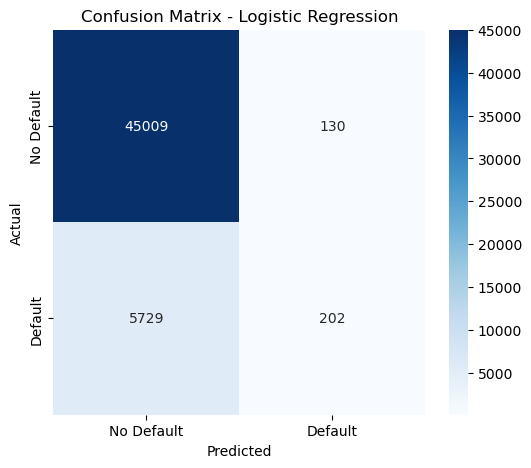

In [98]:
# Classification Report and Confusion Matrix

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred
    )
)

cm = confusion_matrix(
    y_test,
    y_test_pred
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Default', 'Default'],
    yticklabels=['No Default', 'Default']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

# Week 3 Gradient Descent From Scratch

In [105]:
# Prepare NumPy Arrays

X_train_np = X_train_scaled.values.astype(float)

X_test_np = X_test_scaled.values.astype(float)

y_train_np = y_train.values.astype(float)

y_test_np = y_test.values.astype(float)

In [106]:
X_train_gd = np.c_[np.ones(X_train_np.shape[0]), X_train_np]

X_test_gd = np.c_[np.ones(X_test_np.shape[0]), X_test_np]

In [107]:
n_samples = X_train_gd.shape[0]

n_features = X_train_gd.shape[1]

weights = np.zeros(n_features)

learning_rate = 0.01

epochs = 1000

loss_history = []

In [108]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [109]:
# Binary Cross-Entropy Loss

def binary_cross_entropy(y_true, y_pred):

    epsilon = 1e-15

    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    loss = -np.mean(
        y_true * np.log(y_pred)
        +
        (1 - y_true) * np.log(1 - y_pred)
    )

    return loss

In [111]:
# Gradient Descent

for epoch in range(epochs):

    z = np.dot(
        X_train_gd,
        weights
    )

    y_pred = sigmoid(z)

    loss = binary_cross_entropy(
        y_train_np,
        y_pred
    )

    loss_history.append(loss)

    gradient = (
        np.dot(
            X_train_gd.T,
            (y_pred - y_train_np)
        )
        / n_samples
    )

    weights = weights - (
        learning_rate * gradient
    )

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch} | Loss = {loss:.6f}"
        )

Epoch 0 | Loss = 0.343795
Epoch 100 | Loss = 0.339630
Epoch 200 | Loss = 0.336268
Epoch 300 | Loss = 0.333517
Epoch 400 | Loss = 0.331241
Epoch 500 | Loss = 0.329340
Epoch 600 | Loss = 0.327737
Epoch 700 | Loss = 0.326375
Epoch 800 | Loss = 0.325209
Epoch 900 | Loss = 0.324206


In [112]:
print("Final Loss :", loss_history[-1])

Final Loss : 0.32334512554619044


In [113]:
print("Final Weights:")
for feature, weight in zip(['Intercept'] + list(X_train.columns), weights):
    print(f"{feature}: {weight}")

Final Weights:
Intercept: -1.9703327153599564
Age: -0.38670229234401854
Income: -0.22852805416509753
LoanAmount: 0.20023750063234108
CreditScore: -0.08145934693868097
MonthsEmployed: -0.22448471663336372
NumCreditLines: 0.06628838786477671
InterestRate: 0.3047993762313768
LoanTerm: 0.002342949540921547
DTIRatio: 0.0464686842845087
Education_High School: 0.03412430536214512
Education_Master's: -0.030370944026504636
Education_PhD: -0.043073283663299385
EmploymentType_Part-time: 0.04028569319069295
EmploymentType_Self-employed: 0.029785534303545136
EmploymentType_Unemployed: 0.09438724368078544
MaritalStatus_Married: -0.058156128022041786
MaritalStatus_Single: -0.008337849356127832
HasMortgage_Yes: -0.0519041924944265
HasDependents_Yes: -0.08378566895236075
LoanPurpose_Business: 0.02174565269951209
LoanPurpose_Education: 0.0033018177722837884
LoanPurpose_Home: -0.04570780834047586
LoanPurpose_Other: 0.0018280231769776923
HasCoSigner_Yes: -0.08779359656428513


In [76]:
# Gradient Descent Prediction

test_probability_gd = sigmoid(
    np.dot(
        X_test_gd,
        weights
    )
)

test_prediction_gd = (
    test_probability_gd >= 0.5
).astype(int)

print(
    "First 20 Predictions:"
)

print(
    test_prediction_gd[:20]
)

First 20 Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [78]:
gd_accuracy = accuracy_score(
    y_test_np,
    test_prediction_gd
)
print("Accuracy : ", gd_accuracy);

Accuracy :  0.8838652829449775


In [ ]:
# Gradient Descent Loss Curve and Confusion Matrix

plt.figure(figsize=(8, 5))

plt.plot(
    range(epochs),
    loss_history
)

plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Gradient Descent Loss Curve')

plt.show()


cm_gd = confusion_matrix(
    y_test_np,
    test_prediction_gd
)

print("Confusion Matrix:")
print(cm_gd)


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_gd,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Default', 'Default'],
    yticklabels=['No Default', 'Default']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Gradient Descent')

plt.show()